# 03 Dynamic IV Robustness
## 동적 IV 강건성

현재 가격만 넣은 모형과 lagged price를 함께 넣은 distributed lag 모형을 비교한다.
핵심은 가격 효과가 현재 시점에만 나타나는지, 시차를 두고 누적되는지 확인하는 것이다.


## Setup
### 설정


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables" / "model_results"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

CATEGORY_LABELS = {
    "cereal": "Cereal",
    "canned_soup": "Canned soup",
    "bottled_juices": "Bottled juices",
    "cookies": "Cookies",
}


In [2]:
def read_csv(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def category_from_path(path):
    name = Path(path).name
    for category in CATEGORY_LABELS:
        if name.startswith(category):
            return category
    return None


def load_category_files(suffix):
    frames = []
    for path in sorted(TABLE_DIR.glob(f"*_only/*_{suffix}.csv")):
        frame = read_csv(path)
        if "category" not in frame.columns:
            frame["category"] = category_from_path(path)
        frames.append(frame)
    if not frames:
        raise FileNotFoundError(f"No files matched suffix: {suffix}")
    return pd.concat(frames, ignore_index=True)


def add_category_label(frame):
    out = frame.copy()
    out["category_label"] = out["category"].map(CATEGORY_LABELS).fillna(out["category"])
    return out


def save_figure(name):
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    return path


## Cumulative dynamic effects
### 누적 동적 효과

각 dynamic specification의 cumulative coefficient를 비교한다.


In [3]:
dynamic = read_csv(TABLE_DIR / "dynamic_checks" / "all_categories_fe_iv_dynamic_distributed_lag.csv")
dynamic = add_category_label(dynamic)

cum = dynamic[
    (dynamic["coefficient_type"] == "cumulative_sum")
    & (dynamic["control_spec"].isin(["B_ccount_only", "C_plus_deal"]))
].copy()

order = ["DL0_current_only", "DL1_current_lag1", "DL2_current_lag1_lag2"]
cum["dynamic_spec"] = pd.Categorical(cum["dynamic_spec"], categories=order, ordered=True)

display(
    cum[["category_label", "dynamic_spec", "control_spec", "coef", "std_error", "t_stat", "n_obs"]]
    .sort_values(["category_label", "control_spec", "dynamic_spec"])
)


,category_label,dynamic_spec,control_spec,coef,std_error,t_stat,n_obs
57,Bottled juices,DL0_current_only,B_ccount_only,-0.185589,0.110130,-1.685172,6113366
65,Bottled juices,DL1_current_lag1,B_ccount_only,0.163672,0.118024,1.386775,5981593
76,Bottled juices,DL2_current_lag1_lag2,B_ccount_only,0.432475,0.125021,3.459223,5852345
59,Bottled juices,DL0_current_only,C_plus_deal,0.398706,0.099402,4.011040,6113366
68,Bottled juices,DL1_current_lag1,C_plus_deal,0.576473,0.106029,5.436944,5981593
80,Bottled juices,DL2_current_lag1_lag2,C_plus_deal,0.695294,0.112378,6.187085,5852345
30,Canned soup,DL0_current_only,B_ccount_only,-0.325995,0.035203,-9.260342,6862202
38,Canned soup,DL1_current_lag1,B_ccount_only,0.034242,0.036657,0.934115,6623906
49,Canned soup,DL2_current_lag1_lag2,B_ccount_only,0.254937,0.037637,6.773541,6389463
32,Canned soup,DL0_current_only,C_plus_deal,0.330782,0.033302,9.932837,6862202


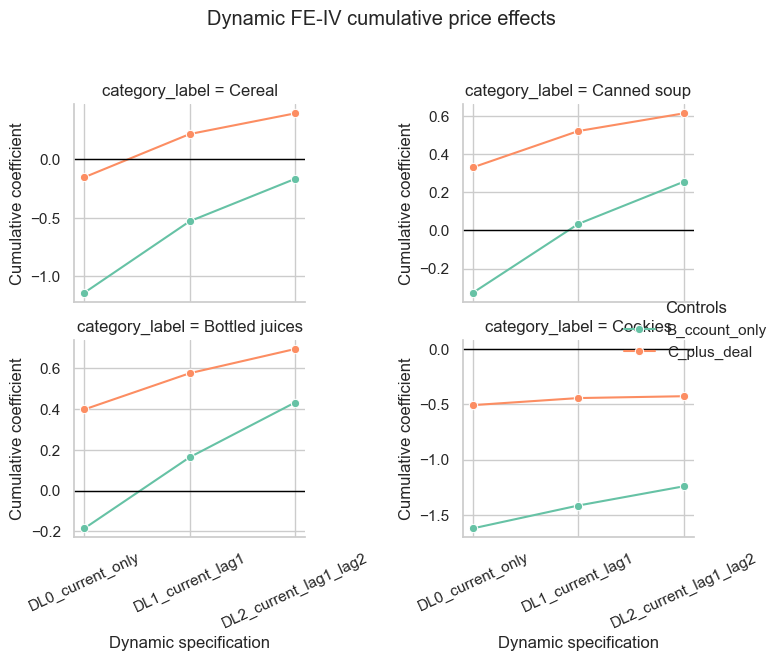

C:\Users\박동하\Documents\Codex\2026-05-16\files-mentioned-by-the-user-untitled48\dominicks-price-elasticity-iv-dml\outputs\figures\dynamic_iv_cumulative_effects.png


In [4]:
g = sns.FacetGrid(cum, col="category_label", hue="control_spec", col_wrap=2, height=3.2, sharey=False, palette="Set2")
g.map_dataframe(sns.lineplot, x="dynamic_spec", y="coef", marker="o")
for ax in g.axes.flatten():
    ax.axhline(0, color="black", linewidth=1)
    ax.tick_params(axis="x", rotation=25)
    ax.set_xlabel("Dynamic specification")
    ax.set_ylabel("Cumulative coefficient")
g.add_legend(title="Controls")
g.fig.suptitle("Dynamic FE-IV cumulative price effects", y=1.03)
path = save_figure("dynamic_iv_cumulative_effects.png")
plt.show()
print(path)


lag를 추가하면 일부 카테고리의 누적 효과가 약해지거나 부호가 바뀐다.
따라서 단순 current-price 결과만으로 장기 가격 반응을 해석하면 과도한 결론이 될 수 있다.


## Cookies memory-safe rerun
### Cookies 메모리 안정 실행 결과

cookies는 관측치가 가장 많아 별도 memory-safe 실행 결과가 포함되어 있다.


In [5]:
cookies_dynamic = read_csv(TABLE_DIR / "dynamic_checks" / "cookies_fe_iv_dynamic_distributed_lag.csv")
cookies_dynamic = cookies_dynamic[cookies_dynamic["coefficient_type"] == "cumulative_sum"].copy()

selected = cookies_dynamic[cookies_dynamic["control_spec"].isin(["A_none", "B_ccount_only", "C_plus_deal"])]
display(selected[["dynamic_spec", "control_spec", "coef", "std_error", "t_stat", "n_obs"]])


,dynamic_spec,control_spec,coef,std_error,t_stat,n_obs
1,DL0_current_only,A_none,-1.497789,0.060305,-24.836932,13150237
3,DL0_current_only,B_ccount_only,-1.620990,0.061466,-26.372272,13150237
5,DL0_current_only,C_plus_deal,-0.507008,0.047278,-10.724010,13150237
8,DL1_current_lag1,B_ccount_only,-1.414539,0.062673,-22.570297,12851279
12,DL2_current_lag1_lag2,B_ccount_only,-1.241210,0.063768,-19.464549,12560085
15,DL1_current_lag1,C_plus_deal,-0.443249,0.048477,-9.143455,12851279
19,DL2_current_lag1_lag2,C_plus_deal,-0.426551,0.050873,-8.384570,12560085
22,DL1_current_lag1,A_none,-1.275452,0.061744,-20.656959,12851279
26,DL2_current_lag1_lag2,A_none,-1.085007,0.063281,-17.145815,12560085


cookies는 lag를 추가해도 음의 누적 효과가 비교적 유지된다.
이 카테고리는 다른 카테고리보다 가격 반응이 강하고 안정적인 편이다.
